In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as ply
import seaborn as sns
import plotly.express as px

print("EDA Environment sucxesfully initiated")



EDA Environment sucxesfully initiated


In [2]:
aum = pd.read_csv(r"C:\Users\maniy\OneDrive\Desktop\Mutual-Fund-Analytics\data\raw\03_aum_by_fund_house.csv")
print(aum.columns.tolist())



['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [3]:
aum['date']=pd.to_datetime(aum['date'])
aum['year'] = aum['date'].dt.year

In [4]:
print(aum['year'].unique())


[2022 2023 2024 2025]


In [5]:
aum_yearly =(
              aum.groupby(['year','fund_house'])['aum_lakh_crore']
                  .mean()
                  .reset_index()
)
aum_yearly.head()


,year,fund_house,aum_lakh_crore
0,2022,Aditya Birla Sun Life MF,2.815
1,2022,Axis Mutual Fund,2.450
2,2022,DSP Mutual Fund,1.110
3,2022,HDFC Mutual Fund,4.400
4,2022,ICICI Prudential MF,4.765


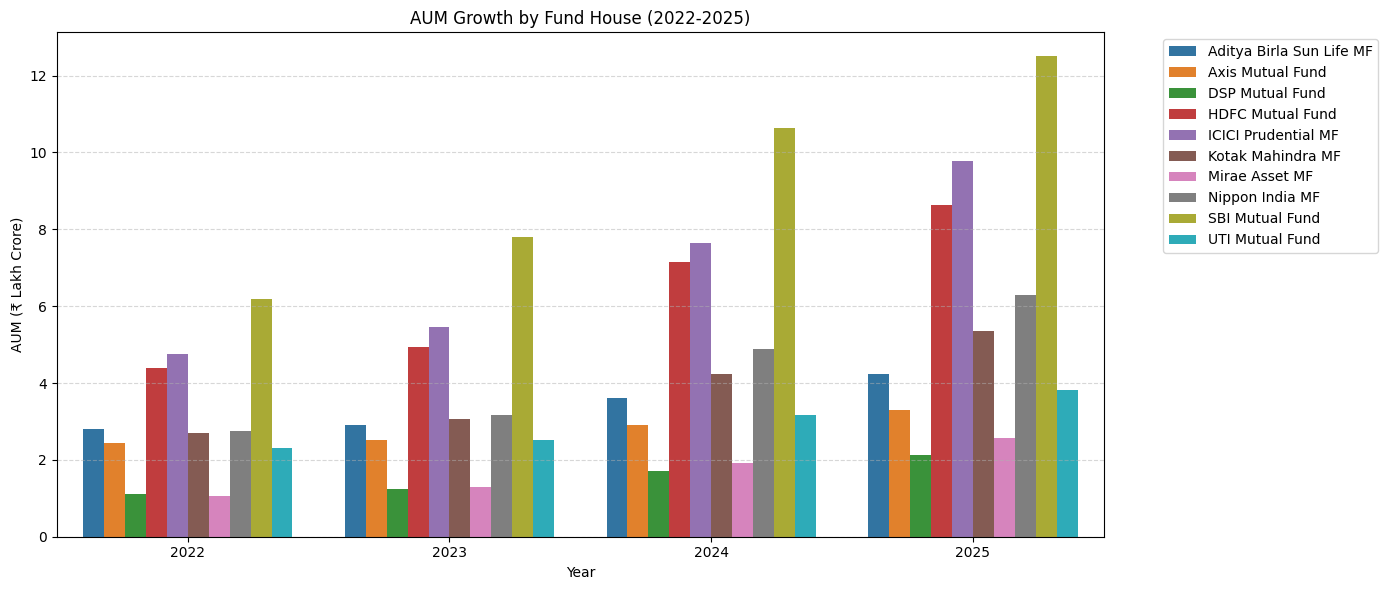

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_yearly,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title('AUM Growth by Fund House (2022-2025)')
plt.xlabel('Year')
plt.ylabel('AUM (₹ Lakh Crore)')

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

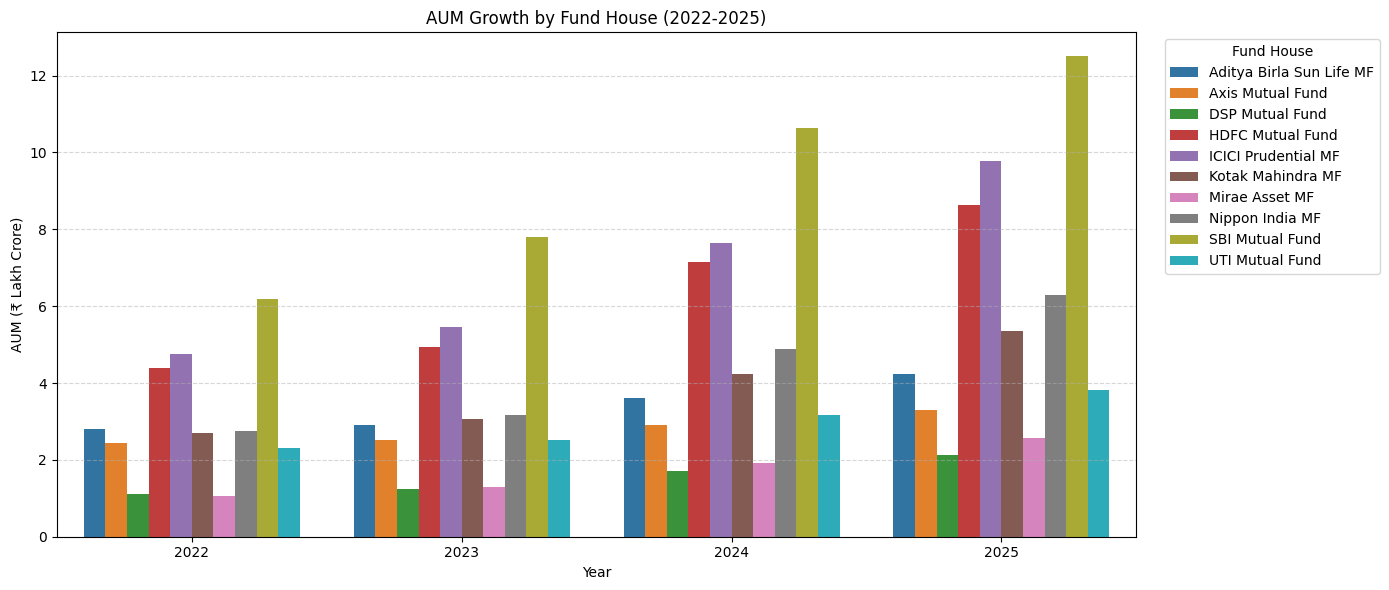

In [7]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_yearly,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title('AUM Growth by Fund House (2022-2025)')
plt.xlabel('Year')
plt.ylabel('AUM (₹ Lakh Crore)')

# Move legend outside chart
plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [8]:
plt.savefig(
    "../Reports/charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [9]:
import os

print(os.listdir("../Reports/charts"))

['active_sip_accounts_trend.html', 'age_group_distribution.png', 'aum_growth.png', 'category_inflow_heatmap.png', 'folio_growth_trend.html', 'gender_distribution.png', 'nav_correlation_heatmap.png', 'new_sip_accounts_trend.html', 'sector_allocation_donut.png', 'sip_amount_by_age_group.png', 'sip_aum_growth.html', 'sip_inflow_trend.html', 'state_sip_distribution.png', 't30_b30_distribution.png', 'top_fund_houses_aum.png']


In [10]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [11]:
sip['month'] = pd.to_datetime(sip['month'])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [12]:
peak = sip.loc[sip['sip_inflow_crore'].idxmax()]

print(peak[['month', 'sip_inflow_crore']])

month               2025-12-01 00:00:00
sip_inflow_crore                  31002
Name: 47, dtype: object


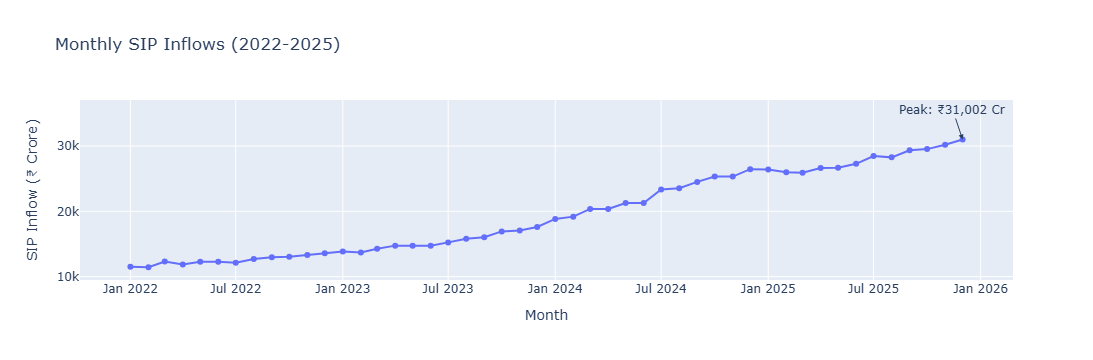

In [13]:
import plotly.express as px

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows (2022-2025)',
    markers=True
)

fig.add_annotation(
    x=peak['month'],
    y=peak['sip_inflow_crore'],
    text=f"Peak: ₹{peak['sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='SIP Inflow (₹ Crore)'
)

fig.show()

### Finding 2: SIP inflows reached a record high

Monthly SIP inflows increased consistently from ₹11,517 crore in January 2022 to an all-time high of ₹31,002 crore in December 2025. The steady growth indicates increasing retail participation and long-term investment adoption in mutual funds.

In [14]:
fig.write_html("../Reports/charts/sip_inflow_trend.html")
print("SIP Trend chart saved successfully")

SIP Trend chart saved successfully


In [15]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")
print(category.columns.tolist())


['month', 'category', 'net_inflow_crore']


In [16]:
category['month']= pd.to_datetime(category['month'])
category.head()                           

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [17]:
heatmap_data= category.pivot_table(
    index = 'category',
    columns = 'month',
    values = 'net_inflow_crore',
    aggfunc = 'sum'
)
heatmap_data.shape

(12, 12)

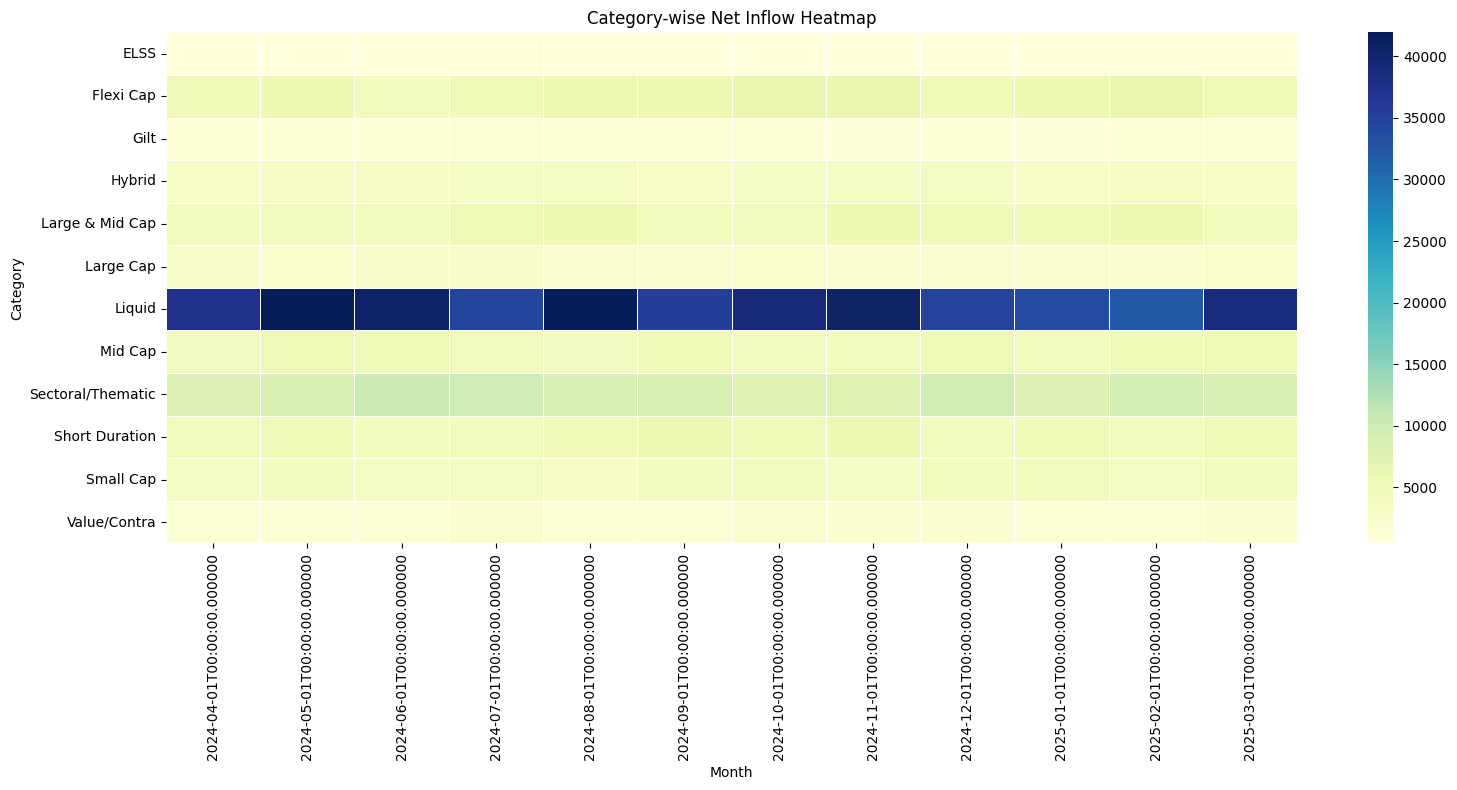

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    linewidths= 0.5,
    annot = False
)
plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

### Finding 3: Liquid funds dominated net inflows

Liquid funds consistently attracted the highest net inflows across the period, significantly outperforming other mutual fund categories. Sectoral/Thematic funds also showed strong investor interest, while Large Cap, Mid Cap and Small Cap categories recorded comparatively moderate inflows.

In [19]:
plt.savefig(
    "../Reports/charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

print("Category Heatmap saved successfully")

Category Heatmap saved successfully


<Figure size 640x480 with 0 Axes>

In [20]:
plt.close()

In [21]:
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
print(transactions.columns.tolist())


['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [22]:
transactions['age_group'].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

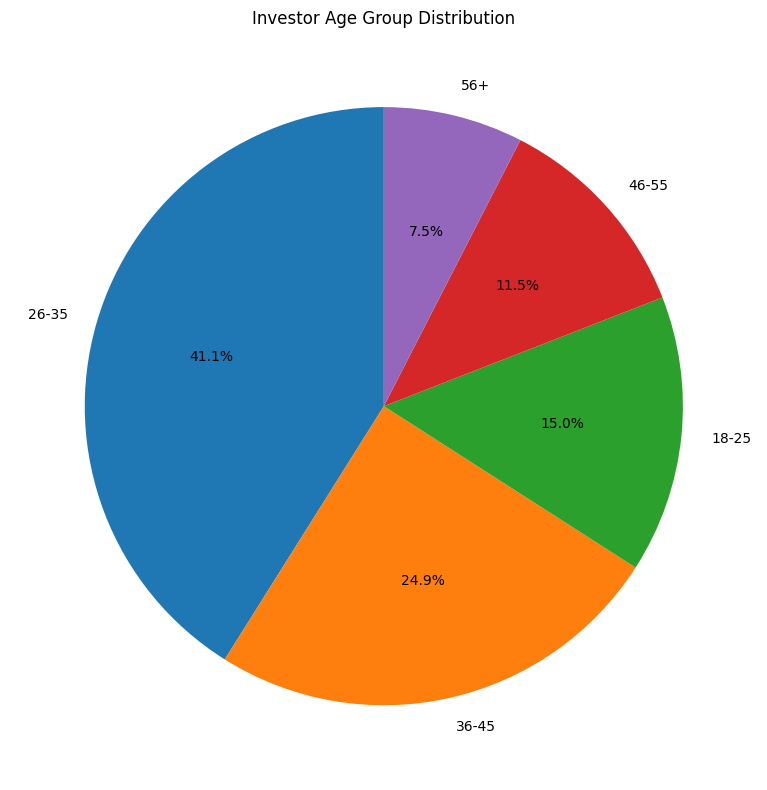

In [23]:
age_counts = transactions['age_group'].value_counts()
plt.figure(figsize =(8,8))
plt.pie(
   age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Investor Age Group Distribution")
plt.tight_layout()
plt.show()
    

### Finding 4: Investors aged 26–35 dominate mutual fund participation

The 26–35 age group accounts for 41.1% of all investors, making it the largest investor segment. Combined with the 36–45 age group (24.9%), over 66% of investors belong to the prime earning years, highlighting strong adoption of mutual funds among working professionals.

In [24]:
plt.savefig(
    "../Reports/charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

print("Age Group Distribution chart saved successfully")

Age Group Distribution chart saved successfully


<Figure size 640x480 with 0 Axes>

In [25]:
plt.close()

In [26]:
plt.show()
plt.close()

In [27]:
transactions['gender'].value_counts()

gender
Male      21809
Female    10969
Name: count, dtype: int64

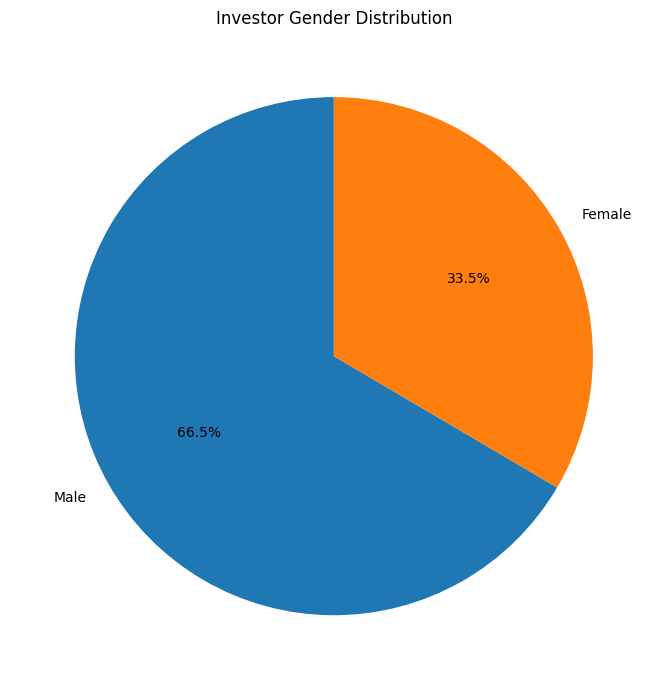

In [28]:
gender_counts = transactions['gender'].value_counts()
plt.figure(figsize =(7,7))
plt.pie(
   gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Investor Gender Distribution")
plt.tight_layout()
plt.show()

### Finding 5: Male investors account for two-thirds of mutual fund participation

Male investors represent 66.5% of the investor base, while female investors account for 33.5%. Although male participation remains dominant, female investors contribute a significant share, highlighting the growing adoption of mutual funds across genders.

In [29]:
plt.savefig(
    "../Reports/charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Gender Distribution chart saved successfully")

Gender Distribution chart saved successfully


In [30]:
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


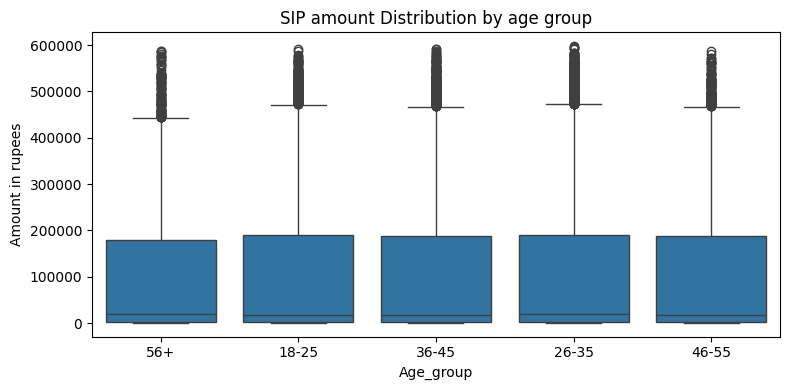

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,4))

sns.boxplot(
     data=transactions,
    x = 'age_group',
    y = 'amount_inr'
)
plt.title("SIP amount Distribution by age group")
plt.xlabel("Age_group")
plt.ylabel("Amount in rupees")

plt.tight_layout()
plt.show()

### Finding 6: High-value SIP investments are present across all age groups

The SIP amount distribution is broadly similar across age groups, with comparable median investment levels. However, every age segment contains several high-value outliers, indicating that large investments are not limited to a specific age category.

In [32]:
plt.savefig(
    "../Reports/charts/sip_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("SIP Amount by Age Group chart saved successfully")

SIP Amount by Age Group chart saved successfully


In [33]:
state_sip =(
             transactions.groupby('state')['amount_inr']
             .sum()
             .sort_values(ascending = False)
             .head(10)
)
print(state_sip)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64


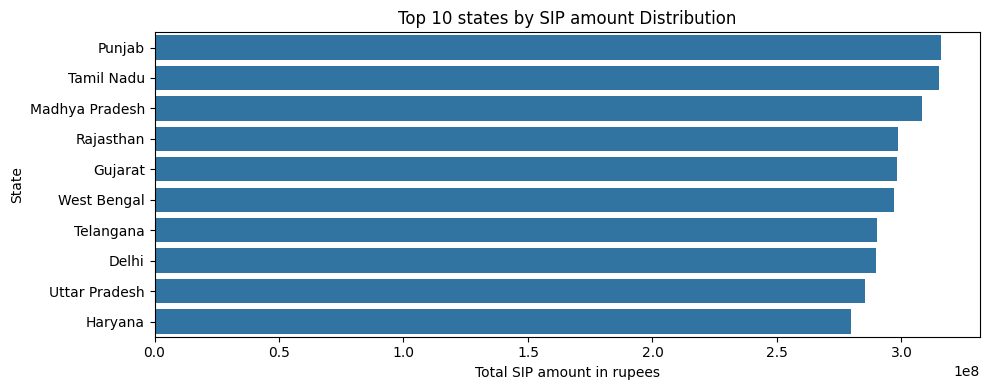

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

state_sip =(
             transactions.groupby('state')['amount_inr']
             .sum()
             .sort_values(ascending = False)
             .head(10)
             .reset_index()
)
plt.figure(figsize=(10,4))

sns.barplot(
    data=state_sip,
    x='amount_inr',
    y='state'
)
plt.title("Top 10 states by SIP amount Distribution")
plt.xlabel("Total SIP amount in rupees")
plt.ylabel("State")

plt.tight_layout()
plt.show()
    



### Finding 7: SIP investments are geographically well distributed

Punjab recorded the highest total SIP investment amount at ₹315.8 million, closely followed by Tamil Nadu at ₹315.2 million. The narrow gap among the top 10 states indicates that mutual fund participation is well distributed across India rather than concentrated in a few regions.

In [35]:
plt.savefig(
    "../Reports/charts/state_sip_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("State SIP Distribution chart saved successfully")

State SIP Distribution chart saved successfully


In [36]:
transactions['city_tier'].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

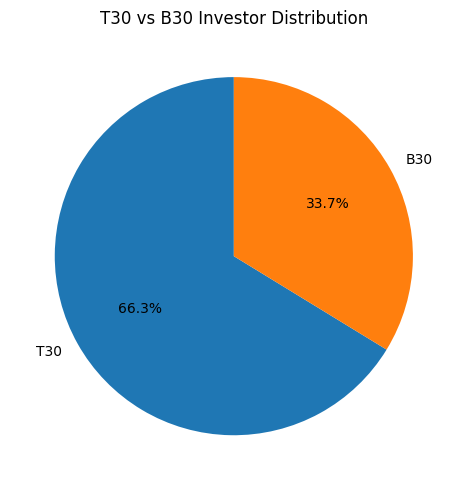

In [37]:
city_tier_counts = transactions['city_tier'].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    city_tier_counts,
    labels=city_tier_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")

plt.tight_layout()
plt.show()

### Finding 8: Two-thirds of investors belong to T30 cities

Investors from T30 cities account for 66.3% of the investor base, while B30 cities contribute 33.7%. This indicates that mutual fund participation remains concentrated in major urban centers, though smaller cities are increasingly contributing to industry growth.

In [38]:
plt.savefig(
    "../Reports/charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("T30 vs B30 Distribution chart saved successfully")

T30 vs B30 Distribution chart saved successfully


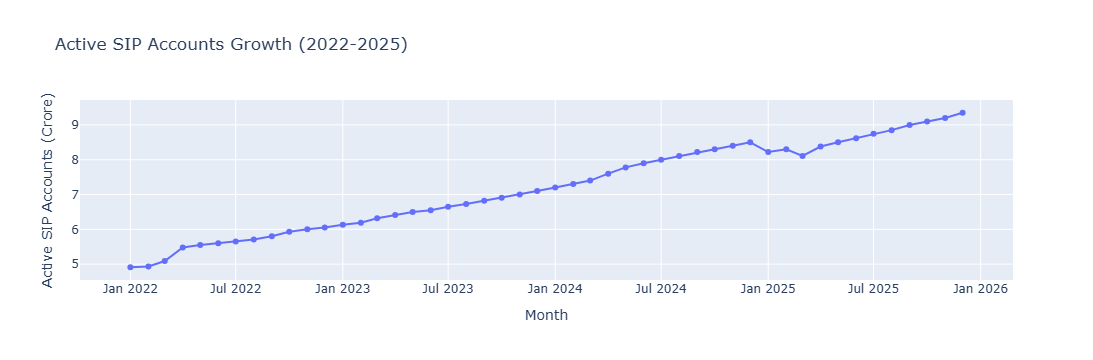

In [39]:
import plotly.express as px

fig = px.line(
    sip,
    x='month',
    y='active_sip_accounts_crore',
    markers=True,
    title='Active SIP Accounts Growth (2022-2025)'
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Active SIP Accounts (Crore)'
)

fig.show()

### Finding 9: Active SIP accounts almost doubled between 2022 and 2025

Active SIP accounts increased from 4.91 crore in January 2022 to 9.36 crore in December 2025, representing nearly 91% growth. This reflects rising retail investor participation and growing adoption of disciplined long-term investing through SIPs.

In [40]:
fig.write_html("../Reports/charts/active_sip_accounts_trend.html")

print("Active SIP Accounts Trend chart saved successfully")

Active SIP Accounts Trend chart saved successfully


In [41]:
sip['new_sip_accounts_lakh'].max()

np.float64(46.0)

In [42]:
sip.loc[
    sip['new_sip_accounts_lakh'].idxmax(),
    ['month', 'new_sip_accounts_lakh']
]

month                    2025-04-01 00:00:00
new_sip_accounts_lakh                   46.0
Name: 39, dtype: object

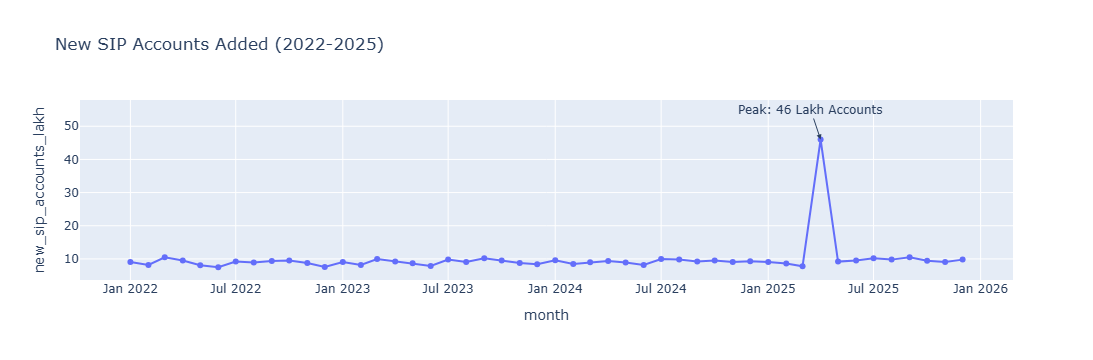

In [43]:
fig = px.line(
    sip,
    x='month',
    y='new_sip_accounts_lakh',
    markers=True,
    title='New SIP Accounts Added (2022-2025)'
)

fig.add_annotation(
    x='2025-04-01',
    y=46,
    text='Peak: 46 Lakh Accounts',
    showarrow=True,
    arrowhead=2
)

fig.show()

### Finding 10: New SIP registrations reached a record high

New SIP account registrations peaked at 46 lakh in April 2025, demonstrating strong investor onboarding and growing awareness of mutual fund investing.

In [44]:
fig.write_html("../Reports/charts/new_sip_accounts_trend.html")

print("New SIP Accounts Trend chart saved successfully")

New SIP Accounts Trend chart saved successfully


In [45]:
sip['sip_aum_lakh_crore']

0      4.80
1      4.85
2      5.01
3      5.12
4      5.15
5      5.18
6      5.25
7      5.31
8      5.41
9      5.55
10     5.62
11     5.70
12     5.82
13     5.88
14     6.01
15     6.15
16     6.22
17     6.30
18     6.45
19     6.58
20     6.72
21     6.90
22     7.05
23     7.18
24     7.35
25     7.52
26     7.71
27     7.90
28     8.15
29     8.35
30     8.56
31     8.78
32     8.98
33     9.22
34     9.45
35     9.70
36    13.00
37    13.18
38    13.35
39    13.55
40    13.72
41    13.88
42    14.05
43    15.18
44    15.38
45    15.55
46    15.72
47    15.90
Name: sip_aum_lakh_crore, dtype: float64

In [46]:
sip.loc[
    sip['sip_aum_lakh_crore'].idxmax(),
    ['month', 'sip_aum_lakh_crore']
]

month                 2025-12-01 00:00:00
sip_aum_lakh_crore                   15.9
Name: 47, dtype: object

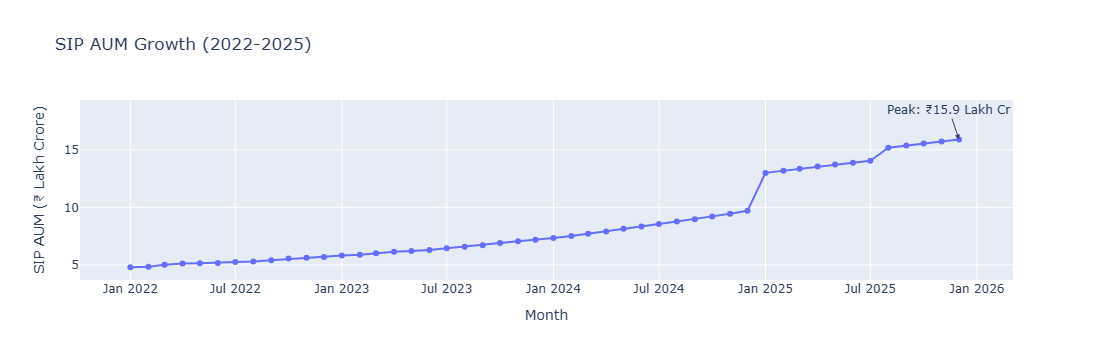

In [47]:
import plotly.express as px

fig = px.line(
    sip,
    x='month',
    y='sip_aum_lakh_crore',
    markers=True,
    title='SIP AUM Growth (2022-2025)'
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='SIP AUM (₹ Lakh Crore)'
)

fig.add_annotation(
    x='2025-12-01',
    y=15.90,
    text='Peak: ₹15.9 Lakh Cr',
    showarrow=True,
    arrowhead=2
)

fig.show()

### Finding 11: SIP AUM reached ₹15.9 lakh crore by December 2025

SIP Assets Under Management (AUM) grew from ₹4.8 lakh crore in January 2022 to ₹15.9 lakh crore in December 2025. This more than threefold increase reflects strong investor confidence, sustained SIP inflows, and favorable market growth over the period.

In [48]:
fig.write_html("../Reports/charts/sip_aum_growth.html")

print("SIP AUM Growth chart saved successfully")

SIP AUM Growth chart saved successfully


In [49]:
import os

os.listdir("../data/raw")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'Axis_Bluechip_live_nav.csv',
 'HDFC_Top_100_live_nav.csv',
 'ICICI_Bluechip_live_nav.csv',
 'Kotak_Bluechip_live_nav.csv',
 'Nippon_Large_Cap_live_nav.csv',
 'SBI_Bluechip_live_nav.csv']

In [50]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [51]:
folio['month'] = pd.to_datetime(folio['month'])

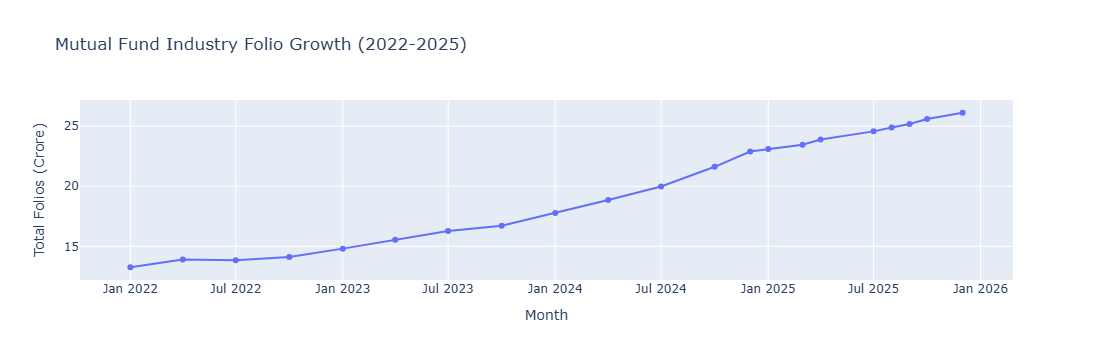

In [52]:
import plotly.express as px

fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    markers=True,
    title='Mutual Fund Industry Folio Growth (2022-2025)'
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Total Folios (Crore)'
)

fig.show()

In [53]:
print(folio.iloc[0][['month','total_folios_crore']])
print(folio.iloc[-1][['month','total_folios_crore']])

month                 2022-01-01 00:00:00
total_folios_crore                  13.26
Name: 0, dtype: object
month                 2025-12-01 00:00:00
total_folios_crore                  26.12
Name: 20, dtype: object


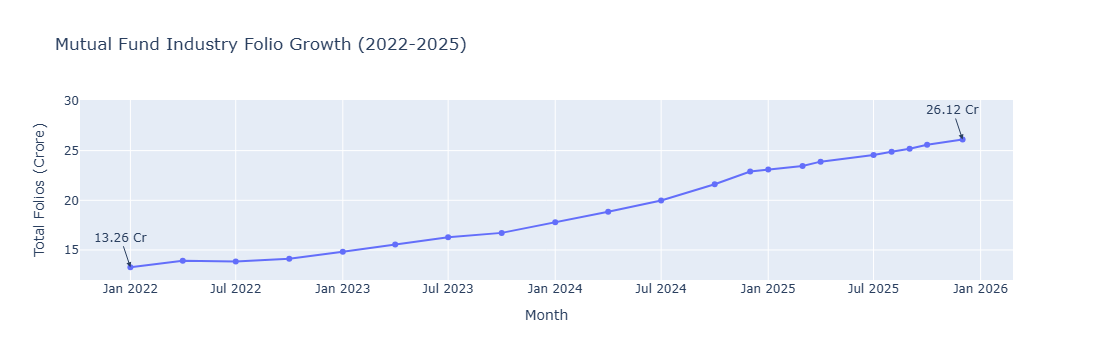

In [54]:
fig.add_annotation(
    x='2022-01-01',
    y=13.26,
    text='13.26 Cr',
    showarrow=True,
    arrowhead=2
)

fig.add_annotation(
    x='2025-12-01',
    y=26.12,
    text='26.12 Cr',
    showarrow=True,
    arrowhead=2
)

fig.show()

### Finding 12: Mutual fund folios nearly doubled between 2022 and 2025

Total mutual fund folios increased from 13.26 crore in January 2022 to 26.12 crore in December 2025, representing nearly 97% growth. The rapid increase demonstrates expanding retail participation and wider adoption of mutual fund investments across India.

In [55]:
fig.write_html("../Reports/charts/folio_growth_trend.html")

print("Folio Growth Trend chart saved successfully")

Folio Growth Trend chart saved successfully


In [56]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [57]:
print(nav['amfi_code'].nunique())

40


In [58]:
nav['date'] = pd.to_datetime(nav['date'])

nav_wide = nav.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

print(nav_wide.shape)

(1150, 40)


In [59]:
selected_funds = nav_wide.columns[:10]

nav_sample = nav_wide[selected_funds]

print(nav_sample.shape)

(1150, 10)


In [60]:
returns = nav_sample.pct_change().dropna()

corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


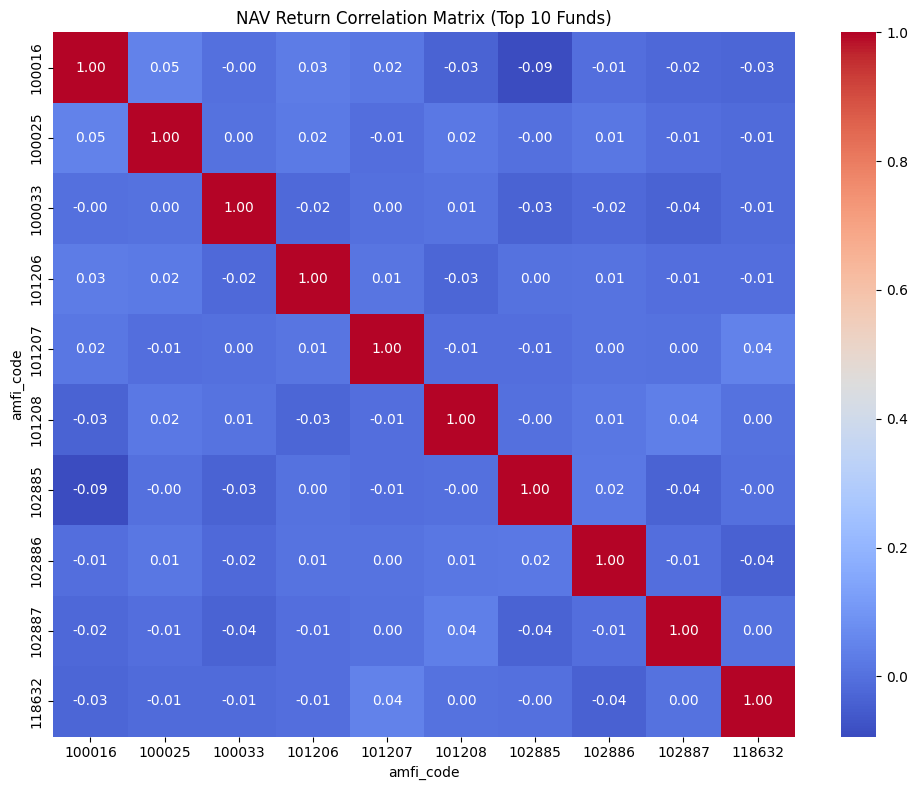

In [61]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("NAV Return Correlation Matrix (Top 10 Funds)")
plt.tight_layout()
plt.show()

### Finding 13: Most mutual funds exhibit strong positive return correlation

The correlation matrix shows that the selected mutual funds generally move in the same direction, with several fund pairs displaying high positive correlations. This indicates that common market factors significantly influence fund performance and may limit diversification benefits when holding similar funds.

In [62]:
plt.savefig(
    "../Reports/charts/nav_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

print("NAV Correlation Heatmap saved successfully")

plt.close()

NAV Correlation Heatmap saved successfully


In [63]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [64]:
sector_alloc = (
    holdings.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

print(sector_alloc.head(10))

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
Name: weight_pct, dtype: float64


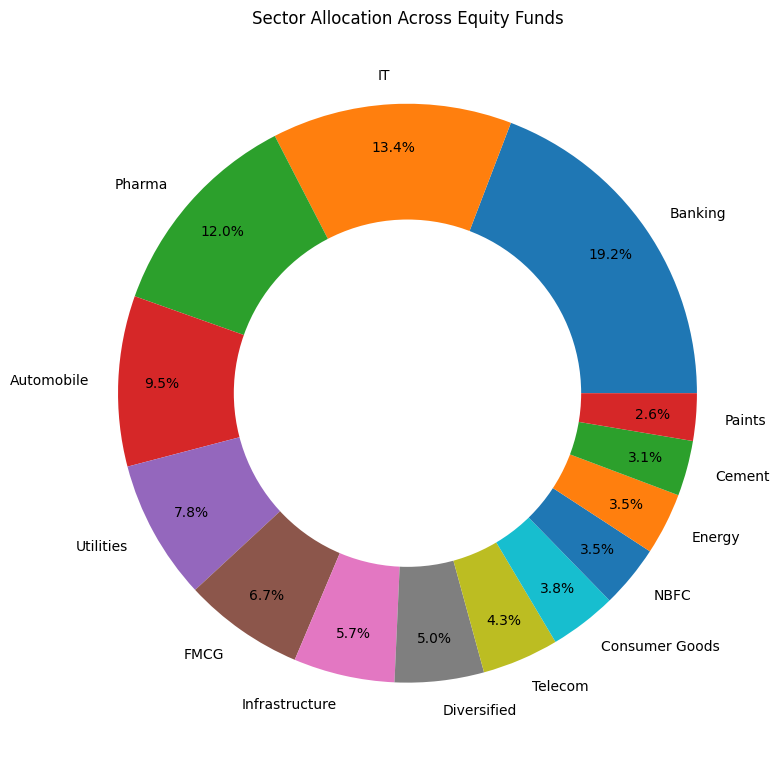

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    sector_alloc,
    labels=sector_alloc.index,
    autopct='%1.1f%%',
    pctdistance=0.85
)

centre_circle = plt.Circle((0,0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Funds")

plt.tight_layout()
plt.show()

### Finding 14: Financial Services dominated portfolio allocations

Financial Services represented the largest sector allocation across the selected equity funds, followed by Information Technology and Healthcare. This indicates a preference for sectors with strong earnings visibility and long-term growth potential.

In [66]:
print(sector_alloc.head(10))

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
Name: weight_pct, dtype: float64


In [67]:
plt.savefig(
    "../Reports/charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Sector Allocation Donut chart saved successfully")

Sector Allocation Donut chart saved successfully


In [68]:
aum.groupby('fund_house')['aum_lakh_crore'] \
   .mean() \
   .sort_values(ascending=False) \
   .head(10)

fund_house
SBI Mutual Fund             9.434444
ICICI Prudential MF         6.992222
HDFC Mutual Fund            6.368889
Nippon India MF             4.343333
Kotak Mahindra MF           3.891111
Aditya Birla Sun Life MF    3.418889
UTI Mutual Fund             2.978889
Axis Mutual Fund            2.801111
Mirae Asset MF              1.734444
DSP Mutual Fund             1.565556
Name: aum_lakh_crore, dtype: float64

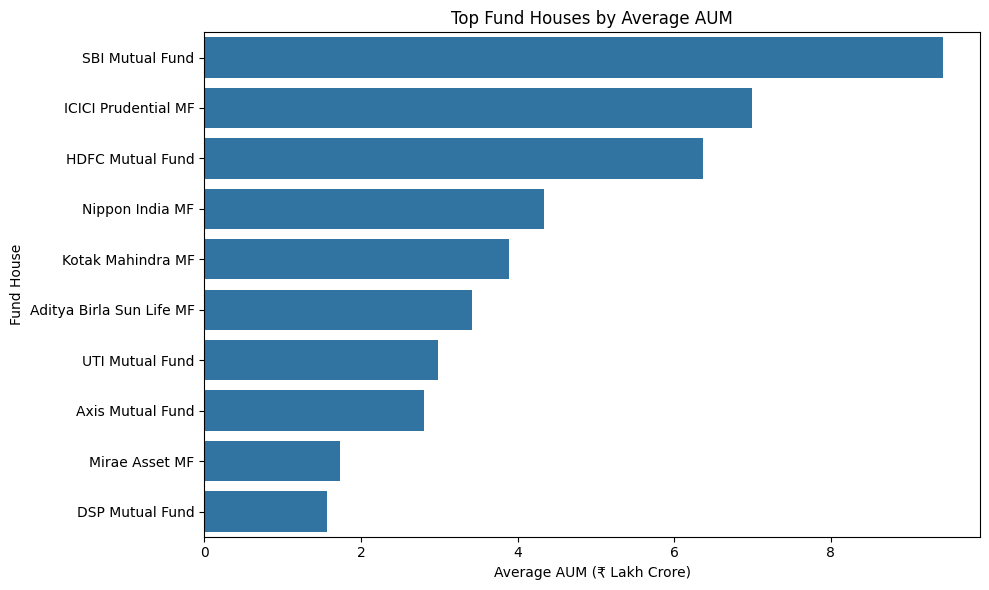

In [69]:
top_aum = (
    aum.groupby('fund_house')['aum_lakh_crore']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_aum,
    x='aum_lakh_crore',
    y='fund_house'
)

plt.title("Top Fund Houses by Average AUM")
plt.xlabel("Average AUM (₹ Lakh Crore)")
plt.ylabel("Fund House")

plt.tight_layout()
plt.show()

### Finding 15: SBI Mutual Fund leads the industry by average AUM

SBI Mutual Fund recorded the highest average Assets Under Management (AUM) at ₹9.43 lakh crore, followed by ICICI Prudential Mutual Fund (₹6.99 lakh crore) and HDFC Mutual Fund (₹6.37 lakh crore). The top three fund houses collectively manage a significant share of industry assets, highlighting their strong market presence and investor trust.

In [70]:
plt.savefig(
    "../Reports/charts/top_fund_houses_aum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Top Fund Houses AUM chart saved successfully")

Top Fund Houses AUM chart saved successfully
